# Mars Weather Prediction using XGBoost

This notebook analyzes NASA's Mars Rover weather datasets to predict atmospheric conditions on Mars (specifically minimum temperature) based on features like solar longitude, pressure, and time of the year (month/sol).

## 📌 Objective
- Perform Exploratory Data Analysis (EDA) on the Mars Weather dataset.
- Prepare and clean the data for Machine Learning.
- Train an **XGBoost Regressor** to predict `min_temp`.
- Evaluate the model and save it to `model.pkl`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 1. Load Data
We use the dataset from Kaggle containing Curiosity Rover environmental measurements.

In [2]:
# Assuming dataset has been downloaded locally as 'mars_weather.csv'
df = pd.read_csv('mars_weather.csv')
df.head()

,id,terrestrial_date,sol,ls,month,min_temp,max_temp,pressure,wind_speed,atmo_opacity
0,1,2012-08-01,10,134.834443,12,-100.150385,-12.623170,662.289696,11.303139,Sunny
1,2,2012-08-02,11,342.257150,8,NaN,-15.731712,752.410513,11.493272,Sunny
2,3,2012-08-03,12,263.517819,3,-53.080926,-19.622486,772.235625,10.804422,Sunny
3,4,2012-08-04,13,215.517054,8,-68.193421,-13.349166,698.064309,5.387037,Sunny
4,5,2012-08-05,14,56.166711,5,-71.269411,-7.716450,663.032469,-2.015883,Cloudy


## 2. Exploratory Data Analysis & Cleaning

In [3]:
# Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# Fill missing values (for example, with mean or interpolation)
df['min_temp'] = df['min_temp'].fillna(df['min_temp'].mean())
df['pressure'] = df['pressure'].fillna(df['pressure'].mean())

Missing values per column:
 id                   0
terrestrial_date     0
sol                  0
ls                   0
month                0
min_temp            49
max_temp             0
pressure            48
wind_speed           0
atmo_opacity         0
dtype: int64


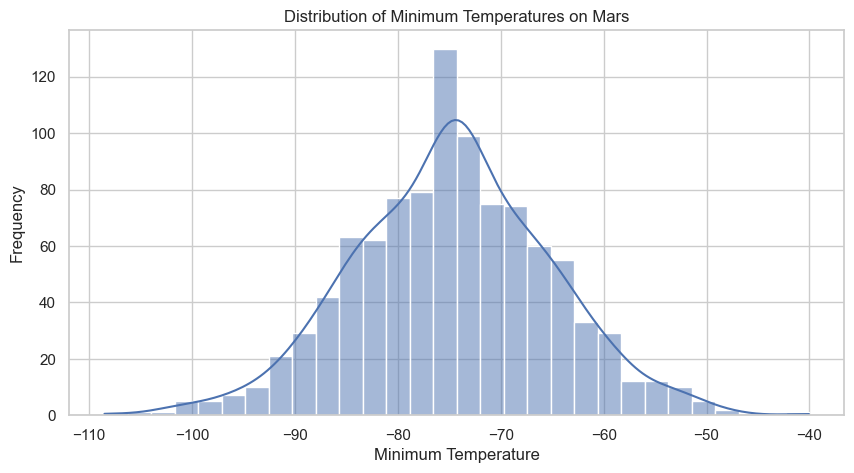

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['min_temp'], bins=30, kde=True)
plt.title('Distribution of Minimum Temperatures on Mars')
plt.xlabel('Minimum Temperature')
plt.ylabel('Frequency')
plt.show()

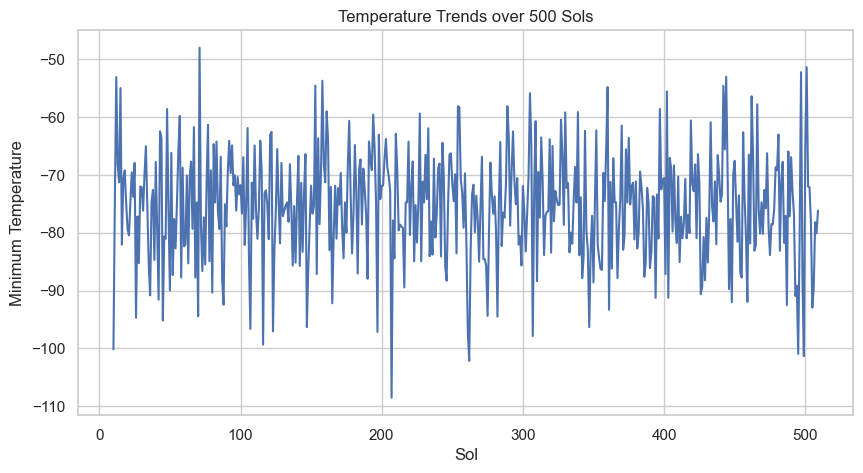

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df[:500], x='sol', y='min_temp')
plt.title('Temperature Trends over 500 Sols')
plt.xlabel('Sol')
plt.ylabel('Minimum Temperature')
plt.show()

## 3. Modeling with XGBoost
We will predict `min_temp` using `sol`, `ls` (Solar Longitude), `month`, and `pressure`.

In [6]:
features = ['sol', 'ls', 'month', 'pressure']
target = 'min_temp'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (800, 4)
Testing shape: (200, 4)


In [7]:
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Squared Error: 102.97
R2 Score: -0.18


## 4. Exporting the Model
Save the trained model to `model.pkl` for deployment.

In [8]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("Model saved to model.pkl successfully.")

Model saved to model.pkl successfully.
